# Gabor filter bank on a real image

We use a small 2D Gabor filter bank on a real image of a brick wall.

## Main idea

For a fixed location $t_0$ and frequency $\omega_0$, one Gabor / STFT coefficient can be read in three equivalent ways.

### 1. Local patch view

$$
\widetilde{V}_w f(t_0,\omega_0)
=
\int_{\mathbb{R}} f(t_0+\tau)\,w(\tau)\,e^{-i\omega_0 \tau}\,d\tau
$$

This is the Fourier coefficient of the local patch centered at $t_0$.

### 2. Global-spectrum view

$$
\widetilde{V}_w f(t_0,\omega_0)
=
\frac{1}{2\pi}
\int_{\mathbb{R}}
\widehat{f}(\xi)\,\widehat{w}(\omega_0-\xi)\,e^{i\xi t_0}\,d\xi
$$

This is the inverse Fourier value at $t_0$ of the global spectrum filtered around $\omega_0$.

### 3. Filter / modulation view

$$
g_{t_0,\omega_0}(t)=w(t-t_0)e^{i\omega_0(t-t_0)},
\qquad
\widehat{g_{t_0,\omega_0}}(\omega)=e^{-i\omega t_0}\,\widehat{w}(\omega-\omega_0)
$$

So the atom is a localized band-pass filter.

## From 1D to 2D

In 2D, the same idea becomes an oriented Gabor filter bank.
Each filter selects:

- a **preferred orientation** $\theta$,
- a **preferred spatial frequency** $f$,
- and a **local neighborhood** because of the Gaussian window.

A typical 2D Gabor atom has the form

$$
g_{\theta,f}(x,y)
=
\exp\!\left(
-\frac{x_\theta^2+y_\theta^2}{2\sigma^2}
\right)
\,e^{\,i\,2\pi f x_\theta}
$$

where

$$
x_\theta = x\cos\theta + y\sin\theta,
\qquad
y_\theta = -x\sin\theta + y\cos\theta
$$

So a Gabor filter bank is a collection of localized, oriented band-pass filters.
On a brick wall image, some filters respond strongly to the dominant texture directions and scales.

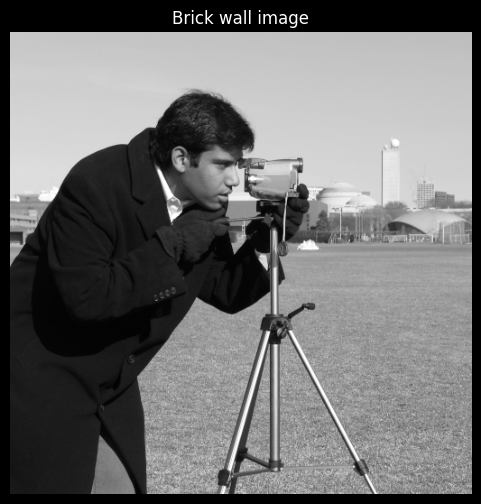

Image shape: (512, 512)
Intensity range: (np.float64(0.0), np.float64(1.0))


In [27]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.filters import gabor, gabor_kernel
# Real image: brick wall
img = img_as_float(data.camera())

# Just in case the image is RGB in some versions
if img.ndim == 3:
    img = img.mean(axis=2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, cmap="gray")
ax.set_title("Brick wall image")
ax.axis("off")
plt.show()

print("Image shape:", img.shape)
print("Intensity range:", (img.min(), img.max()))

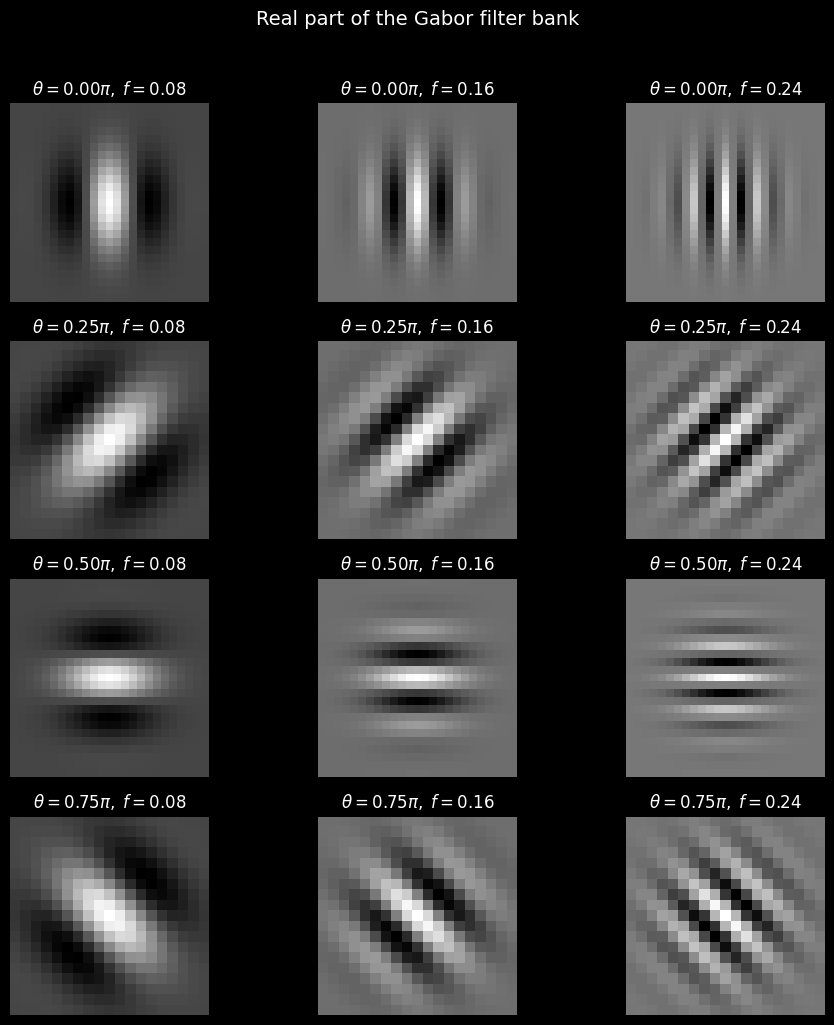

In [28]:
# Small Gabor filter bank
thetas = [0, np.pi/4, np.pi/2, 3*np.pi/4]
frequencies = [0.08, 0.16, 0.24]

fig, axes = plt.subplots(len(thetas), len(frequencies), figsize=(10, 10))

for i, theta in enumerate(thetas):
    for j, freq in enumerate(frequencies):
        kernel = np.real(
            gabor_kernel(
                frequency=freq,
                theta=theta,
                sigma_x=4,
                sigma_y=4
            )
        )

        ax = axes[i, j]
        ax.imshow(kernel, cmap="gray")
        ax.set_title(fr"$\theta={theta/np.pi:.2f}\pi,\; f={freq}$")
        ax.axis("off")

plt.suptitle("Real part of the Gabor filter bank", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

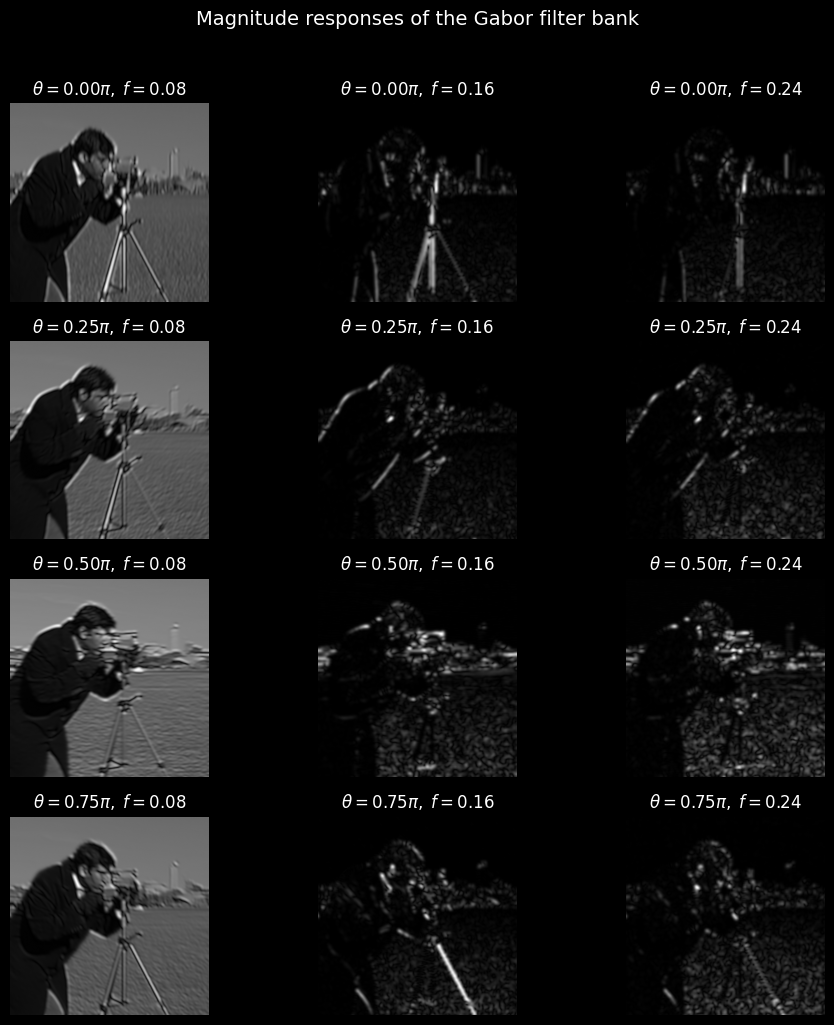

Filters ranked by mean energy per pixel:

theta = 0.25π, frequency = 0.08, mean energy per pixel = 0.007279
theta = 0.75π, frequency = 0.08, mean energy per pixel = 0.007146
theta = 0.00π, frequency = 0.08, mean energy per pixel = 0.006558
theta = 0.50π, frequency = 0.08, mean energy per pixel = 0.006160
theta = 0.00π, frequency = 0.16, mean energy per pixel = 0.000142
theta = 0.50π, frequency = 0.16, mean energy per pixel = 0.000063
theta = 0.75π, frequency = 0.16, mean energy per pixel = 0.000055
theta = 0.25π, frequency = 0.16, mean energy per pixel = 0.000049
theta = 0.00π, frequency = 0.24, mean energy per pixel = 0.000039
theta = 0.50π, frequency = 0.24, mean energy per pixel = 0.000022
theta = 0.25π, frequency = 0.24, mean energy per pixel = 0.000015
theta = 0.75π, frequency = 0.24, mean energy per pixel = 0.000013


In [29]:
# Apply the filter bank and display magnitude responses
fig, axes = plt.subplots(len(thetas), len(frequencies), figsize=(10, 10))
energies = []

for i, theta in enumerate(thetas):
    for j, freq in enumerate(frequencies):
        real, imag = gabor(
            img,
            frequency=freq,
            theta=theta,
            sigma_x=4,
            sigma_y=4
        )

        magnitude = np.sqrt(real**2 + imag**2)
        channel_energy_mean = np.mean(magnitude**2)
        energies.append((theta, freq, channel_energy_mean))

        ax = axes[i, j]
        ax.imshow(magnitude, cmap="gray")
        ax.set_title(fr"$\theta={theta/np.pi:.2f}\pi,\; f={freq}$")
        ax.axis("off")

plt.suptitle("Magnitude responses of the Gabor filter bank", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

energies = sorted(energies, key=lambda x: x[2], reverse=True)

print("Filters ranked by mean energy per pixel:\n")
for theta, freq, e in energies:
    print(f"theta = {theta/np.pi:.2f}π, frequency = {freq:.2f}, mean energy per pixel = {e:.6f}")

## Energy concentration in the small Gabor bank

Now channel-energy quantity:

$$
E_{\theta,f}
=
\frac{1}{MN}\sum_{x,y} |R_{\theta,f}(x,y)|^2,
\qquad
R_{\theta,f} = I * g_{\theta,f}.
$$

Important point:

- for the **full STFT / full Gabor system**, there is a Parseval / Moyal identity,
- but for this **small hand-picked bank**, exact energy conservation is **not** expected.

So here we check something slightly different:

1. how the bank energy is distributed across channels,
2. whether a few $(\theta,f)$ channels capture most of the bank response,
3. which **orientations** and **frequencies** dominate the brick texture.

IMAGE ENERGY
Total image energy        = sum(img^2)  = 89015.009350
Mean image energy/pixel   = mean(img^2) = 0.339565

SMALL GABOR BANK ENERGY
Sum of channel mean energies  = 0.027541 --> in percent of image mean energy: 8.11%
Sum of channel total energies = 7219.677087 --> in percent of image total energy: 8.11%

Ratios relative to image energy
(sum of channel total energies) / (total image energy) = 0.081106
(sum of channel mean energies)  / (mean image energy)  = 0.081106

Channels ranked by mean squared magnitude:
theta = 0.25π, frequency = 0.08, mean energy = 0.007279, total energy = 1908.030263, share = 26.43%
theta = 0.75π, frequency = 0.08, mean energy = 0.007146, total energy = 1873.255549, share = 25.95%
theta = 0.00π, frequency = 0.08, mean energy = 0.006558, total energy = 1719.206493, share = 23.81%
theta = 0.50π, frequency = 0.08, mean energy = 0.006160, total energy = 1614.744434, share = 22.37%
theta = 0.00π, frequency = 0.16, mean energy = 0.000142, total energy = 37.

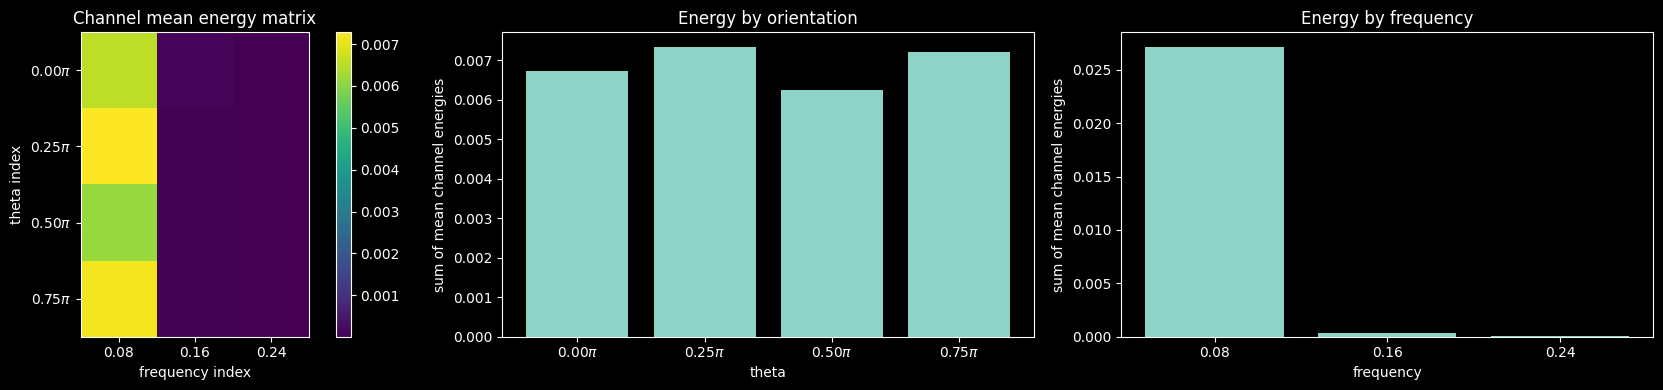

In [30]:
# Energy concentration across the small Gabor bank
channel_energy = np.zeros((len(thetas), len(frequencies)))
channel_info = []

# Total image energy
image_energy_total = np.sum(img**2)
image_energy_mean = np.mean(img**2)

for i, theta in enumerate(thetas):
    for j, freq in enumerate(frequencies):
        real, imag = gabor(
            img,
            frequency=freq,
            theta=theta,
            sigma_x=4,
            sigma_y=4
        )

        magnitude_sq = real**2 + imag**2

        # Average energy per pixel in this channel
        E_mean = np.mean(magnitude_sq)

        # Total energy in this channel
        E_total = np.sum(magnitude_sq)

        channel_energy[i, j] = E_mean
        channel_info.append((theta, freq, E_mean, E_total))

total_bank_energy_mean = channel_energy.sum()
total_bank_energy_total = sum(x[3] for x in channel_info)

channel_info_sorted = sorted(channel_info, key=lambda x: x[2], reverse=True)

print("IMAGE ENERGY")
print(f"Total image energy        = sum(img^2)  = {image_energy_total:.6f}")
print(f"Mean image energy/pixel   = mean(img^2) = {image_energy_mean:.6f}")

print("\nSMALL GABOR BANK ENERGY")
print(f"Sum of channel mean energies  = {total_bank_energy_mean:.6f} --> in percent of image mean energy: {100*total_bank_energy_mean/image_energy_mean:.2f}%")
print(f"Sum of channel total energies = {total_bank_energy_total:.6f} --> in percent of image total energy: {100*total_bank_energy_total/image_energy_total:.2f}%")

print("\nRatios relative to image energy")
print(f"(sum of channel total energies) / (total image energy) = "
      f"{total_bank_energy_total / image_energy_total:.6f}")
print(f"(sum of channel mean energies)  / (mean image energy)  = "
      f"{total_bank_energy_mean / image_energy_mean:.6f}")

print("\nChannels ranked by mean squared magnitude:")
for theta, freq, E_mean, E_total in channel_info_sorted:
    share = 100 * E_mean / total_bank_energy_mean
    print(f"theta = {theta/np.pi:.2f}π, frequency = {freq:.2f}, "
          f"mean energy = {E_mean:.6f}, total energy = {E_total:.6f}, "
          f"share = {share:5.2f}%")

# Cumulative contribution of strongest channels
cum = 0.0
print("\nCumulative contribution of the strongest channels:")
for rank, (_, _, E_mean, _) in enumerate(channel_info_sorted, start=1):
    cum += E_mean
    print(f"Top {rank:2d}: cumulative share = {100*cum/total_bank_energy_mean:6.2f}%")

# ------------------------------------------------------------
# Aggregate by orientation and by frequency
# ------------------------------------------------------------
energy_by_theta = channel_energy.sum(axis=1)   # sum over frequencies
energy_by_freq = channel_energy.sum(axis=0)    # sum over angles

print("\nEnergy grouped by orientation:")
for theta, E in zip(thetas, energy_by_theta):
    print(f"theta = {theta/np.pi:.2f}π -> {E:.6f}  ({100*E/total_bank_energy_mean:5.2f}%)")

print("\nEnergy grouped by frequency:")
for freq, E in zip(frequencies, energy_by_freq):
    print(f"frequency = {freq:.2f} -> {E:.6f}  ({100*E/total_bank_energy_mean:5.2f}%)")

# How many channels are needed to capture 80%, 90%, 95% of bank energy?
cumvals = np.cumsum([x[2] for x in channel_info_sorted]) / total_bank_energy_mean
for target in [0.80, 0.90, 0.95]:
    k = np.searchsorted(cumvals, target) + 1
    print(f"\nNumber of channels needed to reach {int(100*target)}% of bank energy: {k}")

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

im = axes[0].imshow(channel_energy, cmap="viridis")
axes[0].set_title("Channel mean energy matrix")
axes[0].set_xlabel("frequency index")
axes[0].set_ylabel("theta index")
axes[0].set_xticks(range(len(frequencies)))
axes[0].set_xticklabels([f"{f:.2f}" for f in frequencies])
axes[0].set_yticks(range(len(thetas)))
axes[0].set_yticklabels([fr"{th/np.pi:.2f}$\pi$" for th in thetas])
plt.colorbar(im, ax=axes[0])

axes[1].bar(range(len(thetas)), energy_by_theta)
axes[1].set_title("Energy by orientation")
axes[1].set_xlabel("theta")
axes[1].set_ylabel("sum of mean channel energies")
axes[1].set_xticks(range(len(thetas)))
axes[1].set_xticklabels([fr"{th/np.pi:.2f}$\pi$" for th in thetas])

axes[2].bar(range(len(frequencies)), energy_by_freq)
axes[2].set_title("Energy by frequency")
axes[2].set_xlabel("frequency")
axes[2].set_ylabel("sum of mean channel energies")
axes[2].set_xticks(range(len(frequencies)))
axes[2].set_xticklabels([f"{f:.2f}" for f in frequencies])

plt.tight_layout()
plt.show()

## Interpretation

- If a few channels already explain most of the bank energy, then the texture is well described by a small set of preferred **orientations** and **frequencies**.
- If many channels contribute similarly, then the texture is less selective.

For the brick wall, you should typically see that:

- only a few channels carry most of the response,
- some orientations dominate because the wall has preferred directions,
- very high-frequency channels often contribute much less.

But this does **not** mean exact signal-energy conservation for the small bank.
It only shows **energy concentration inside this chosen bank**.

Exact conservation belongs to the **full STFT / tight Gabor frame** setting.

## What this notebook shows

- Each Gabor filter is a **localized, oriented band-pass probe**.
- For each pixel, the filter bank asks:
  - which orientation fits best here?
  - which spatial frequency fits best here?
- The map of strongest response shows where the image contains texture aligned with one of the bank filters.
- The orientation map shows which filter direction best matches the local brick pattern.
- This is the 2D image version of the same idea as the STFT:
  - **local patch Fourier measurement**
  - **filtered global spectrum**
  - **response to a localized band-pass atom**e